In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

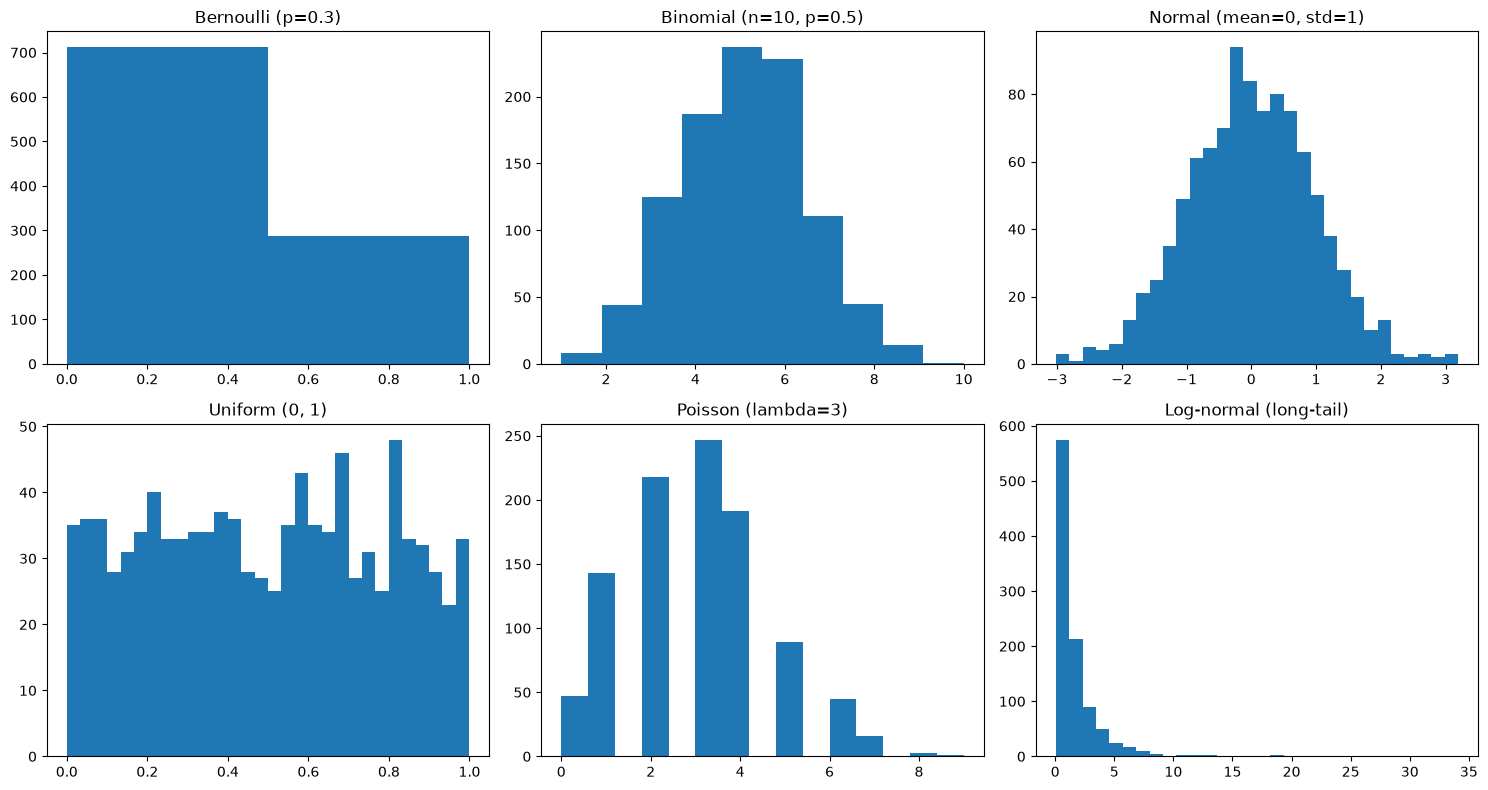

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Bernoulli
bernoulli_samples = np.random.binomial(1, 0.3, 1000)
axes[0, 0].hist(bernoulli_samples, bins=2)
axes[0, 0].set_title('Bernoulli (p=0.3)')

# Binomial
binomial_samples = np.random.binomial(10, 0.5, 1000)
axes[0, 1].hist(binomial_samples, bins=10)
axes[0, 1].set_title('Binomial (n=10, p=0.5)')

# Normal
normal_samples = np.random.normal(0, 1, 1000)
axes[0, 2].hist(normal_samples, bins=30)
axes[0, 2].set_title('Normal (mean=0, std=1)')

# Uniform
uniform_samples = np.random.uniform(0, 1, 1000)
axes[1, 0].hist(uniform_samples, bins=30)
axes[1, 0].set_title('Uniform (0, 1)')

# Poisson
poisson_samples = np.random.poisson(3, 1000)
axes[1, 1].hist(poisson_samples, bins=15)
axes[1, 1].set_title('Poisson (lambda=3)')

# Log-normal (long-tail)
lognormal_samples = np.random.lognormal(0, 1, 1000)
axes[1, 2].hist(lognormal_samples, bins=30)
axes[1, 2].set_title('Log-normal (long-tail)')

plt.tight_layout()
plt.show()

## Where These Distributions Appear

- **Bernoulli**: single yes/no event (e.g., did a user click an ad?)
- **Binomial**: number of successes in n trials (e.g., 10 coin flips)
- **Normal**: heights, measurement errors, many natural phenomena
- **Uniform**: random number generators, equally likely outcomes
- **Poisson**: count of rare events in a fixed interval (e.g., 
  customer arrivals per hour)
- **Log-normal**: quantities that are products of many factors — 
  income, stock prices, city populations (long right tail)

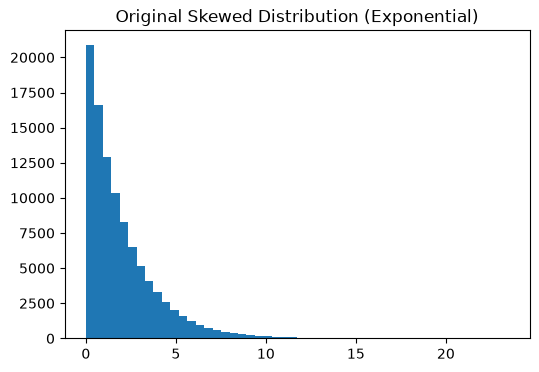

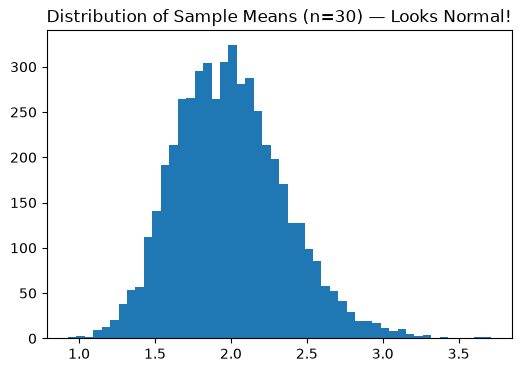

In [3]:
# Start with a skewed distribution (exponential)
skewed_population = np.random.exponential(scale=2, size=100000)

plt.figure(figsize=(6, 4))
plt.hist(skewed_population, bins=50)
plt.title('Original Skewed Distribution (Exponential)')
plt.show()

# Now take many samples, average each, and plot those averages
sample_means = []
for _ in range(5000):
    sample = np.random.choice(skewed_population, size=30)
    sample_means.append(sample.mean())

plt.figure(figsize=(6, 4))
plt.hist(sample_means, bins=50)
plt.title('Distribution of Sample Means (n=30) — Looks Normal!')
plt.show()

## Central Limit Theorem

Even though the original population is skewed (exponential), the 
distribution of sample means becomes approximately normal as we 
average larger samples. This is the Central Limit Theorem in 
action — it's why normal distribution assumptions are often 
reasonable for averages, even when raw data isn't normal.

## Bayes Drill: Medical Test Problem

**Given:**
- Prevalence: P(Disease) = 0.01
- Sensitivity: P(Positive | Disease) = 0.95
- Specificity: P(Negative | No Disease) = 0.90, so 
  P(Positive | No Disease) = 0.10

**Find:** P(Disease | Positive)

**Bayes' Theorem:**

P(Disease | Positive) = [P(Positive | Disease) x P(Disease)] / P(Positive)

P(Positive) = P(Positive | Disease) x P(Disease) + P(Positive | No Disease) x P(No Disease)
            = (0.95 x 0.01) + (0.10 x 0.99)
            = 0.0095 + 0.099
            = 0.1085

P(Disease | Positive) = 0.0095 / 0.1085 ≈ 0.0876 (about 8.76%)

**Key insight:** Even with a positive test, there's only an ~8.76% 
chance of actually having the disease — because the disease is 
rare (low prevalence), most positive results are false positives.

In [4]:
n_patients = 1_000_000
has_disease = np.random.random(n_patients) < 0.01

test_positive = np.zeros(n_patients, dtype=bool)
test_positive[has_disease] = np.random.random(has_disease.sum()) < 0.95
test_positive[~has_disease] = np.random.random((~has_disease).sum()) < 0.10

prob_disease_given_positive = has_disease[test_positive].mean()
print(f"Simulated P(Disease | Positive) = {prob_disease_given_positive:.4f}")
print(f"Hand-calculated value = 0.0876")

Simulated P(Disease | Positive) = 0.0869
Hand-calculated value = 0.0876


In [5]:
titanic = pd.read_csv('../data/processed/titanic_cleaned.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [6]:
def bootstrap_ci(data, n_bootstrap=10000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())
    
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(boot_means), lower, upper

mean_age, lower, upper = bootstrap_ci(titanic['Age'].dropna().values)
print(f"Bootstrap 95% CI for mean Age: [{lower:.2f}, {upper:.2f}]")
print(f"Point estimate: {mean_age:.2f}")

Bootstrap 95% CI for mean Age: [28.52, 30.22]
Point estimate: 29.36


In [7]:
# Overall survival rate by class
overall = titanic.groupby('Pclass', observed=True)['Survived'].apply(
    lambda x: (x.astype(int) == 1).mean()
)
print("Survival rate by Pclass (overall):\n", overall)

# Now split by Sex within each class
by_sex_class = titanic.groupby(['Pclass', 'Sex'], observed=True)['Survived'].apply(
    lambda x: (x.astype(int) == 1).mean()
)
print("\nSurvival rate by Pclass AND Sex:\n", by_sex_class)

Survival rate by Pclass (overall):
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Pclass AND Sex:
 Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


## Simpson's Paradox Example

Looking at survival rates by Pclass alone suggests class strongly 
determines survival. But when we split by Sex within each class, 
we see the real driver: women survived at high rates across all 
classes, and men survived at low rates across all classes. Pclass 
appeared to matter partly because 1st class had a higher proportion 
of women — a confounding variable. This illustrates Simpson's 
Paradox: aggregated trends can mask or reverse when a confounder 
(Sex) is properly accounted for.

## Why Squared Error = Gaussian Noise Assumption

If we assume prediction errors are normally distributed 
(y = prediction + Gaussian noise), the likelihood of observing 
the data is proportional to:

    exp(-(y - prediction)^2 / (2 * sigma^2))

Maximising this likelihood is the same as minimising 
(y - prediction)^2, summed over all data points — which is exactly 
the squared error loss. So using MSE as a loss function implicitly 
assumes your errors are Gaussian.

## Why Cross-Entropy = Maximum Likelihood for Classification

For classification, we model the outcome as a Bernoulli/categorical 
distribution — each label has some probability. The likelihood of 
observing the true labels, given predicted probabilities, is:

    product of p_i (for each true label i)

Taking the negative log of this likelihood gives:

    -sum(log(p_i))

This is exactly the cross-entropy loss. So minimising cross-entropy 
is the same as maximising the likelihood of the observed labels 
under your predicted probability distribution.

In [8]:
from scipy.stats import norm

def sample_size_for_ab_test(p1, p2, alpha=0.05, power=0.8):
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    p_avg = (p1 + p2) / 2
    n = ((z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + 
          z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (p1 - p2) ** 2
    return int(np.ceil(n))

# Example: baseline 10% conversion, detect a 2-point difference (10% vs 12%)
n_required = sample_size_for_ab_test(0.10, 0.12)
print(f"Required sample size per group: {n_required}")

Required sample size per group: 3841
